# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 25 - 3er bimestre 2026

## **Alumno:** Ruiz Santiago

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 17 de julio (hora de Argentina)**.

La resolución del TP debe realizarse en **parejas**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que ambos deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta. También está permitido realizar el trabajo de forma **individual** si así lo desean, aunque esta modalidad no es la más recomendable.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/xC3HzHwVqt35M23c7)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP1-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP1-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-1, fin=1`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado). Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger. Pero tampoco vale usar una `tanh` sola, usen otra función, o si la van a usar debe estar combinada con otros patrones no lineales. Ya que al ser la función de activación tambien una `tanh`, el modelo la tendrá muy fácil converger a ella.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para cada uno de los 3 learning rates. Las 3 gráficas deben estar en el mismo plot y superpuestas para que la comparación visual sea más fácil. Deben graficarlas con diferente color y con leyenda para no confundirlas.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate. Y las leyendas deben diferenciar al optimizador por color.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes. Le voy a tomar mucha importancia a este último punto, así que su análisis debe ser claro, detallado y con criterio acorde a los resultados obtenidos.

### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia. La comparación debe ser clara y detallada.

### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual. Y la idea sería que una vez que el modelo ya esté listo y entrenado, se use para estimar apartir de datos de clientes relativamente nuevos, que solo llevan entre 3 a 5 visitas y compras en la tienda.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage, ocurre mucho cuando se usan proporciones como nuevas columnas**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.

---

# $$--- RESOLUCIÓN ---$$

## PREGUNTA 1

## a) Implementación de GD

En la elección del dataset sintético, se tuvo en cuenta que $ \hat{y} = \tanh(w x + b) $, por lo que si $x$ tiene valores muy grandes en magnitud, es más propenso que $ w x + b $ caiga en zona de saturación de la $tanh$, donde la derivada es prácticamente 0, cuando $w$ crezca un poco durante el entrenamiento.
Con un rango más acotado, es más difícil de saturar y se puede encontrar una convergencia más fácil en todos los optimizadores.

Dicho esto, se evita trabajar con un polinomio de grado muy alto o con oscilaciones muy rápidas, porque con una sola neurona con $ tanh $ no tenemos mucha capacidad para aproximar eso y realizar una buena comparativa de optimizadores. La elección es usar la siguiente función:

$$ f(x) = sin(2x) + 0.15x^2 $$

Para el ruido, se agrega un ruido gaussiano con un sigma chico, relativo a la escala de $f(x)$, ya que si el ruido es demasiado grande puede afectar a la comparación de los optimizadores. 

Verificación de los valores de y: -1.097529938531144 2.0442267154037905
Cantidad de datos: 300


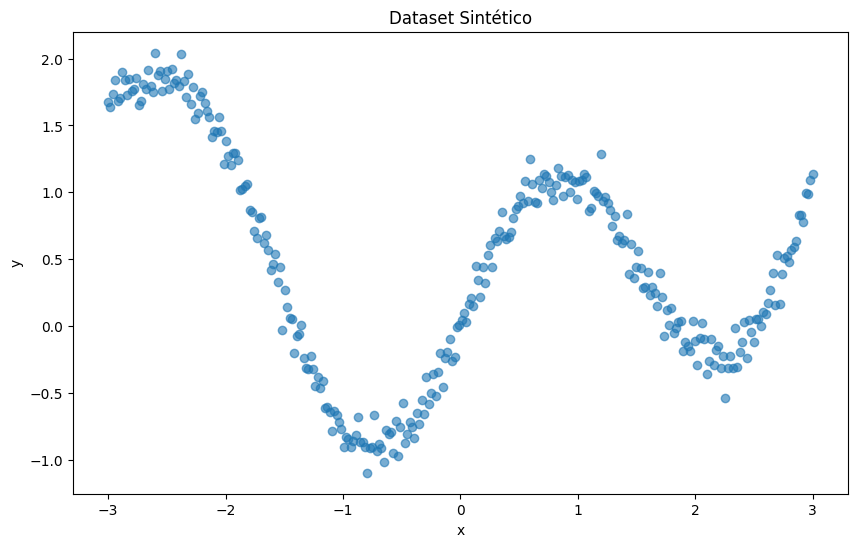

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

# --- Dataset sintético ---
np.random.seed(42)
n = 300
ini, fin = -3, 3
x = np.linspace(ini, fin, n)

f_x = np.sin(2*x) + 0.15*x**2

ruido = np.random.normal(0, 0.1, n)

y = f_x + ruido

print('Verificación de los valores de y:', y.min(), y.max())
print('Cantidad de datos:', len(y))

# --- Visualización de los datos ---
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dataset Sintético')
plt.show()

A continuación, se presenta la implementación de Gradiente Descendente (GD). Para el mismo, se definen las funciones **forward**, que devuelve el valor de $y_hat$, **cost**, que utiliza el error cuadrático medio como función de costo, y **gradients**, donde se calculan las derivadas necesarias aplicando regla de la cadena. Detallando este último paso, se necesitan las siguientes derivadas:

##### Derivada parcial de la función de costo respecto a $w$
$$
\frac{\partial J}{\partial w} = \frac{\partial J}{\partial \hat y_i} · \frac{\partial \hat y_i}{\partial z_i} · \frac{\partial z_i}{\partial w}
$$

##### Derivada parcial de la función de costo respecto a $b$
$$
\frac{\partial J}{\partial b} = \frac{\partial J}{\partial \hat y_i} · \frac{\partial \hat y_i}{\partial z_i} · \frac{\partial z_i}{\partial b}
$$

##### Derivada parcial de la función de costo respecto a $\hat y_i$

$$
\frac{\partial J}{\partial \hat y_i} = \frac{2}{m} (\hat y_i - y_i)
$$

##### Derivada parcial de $\hat y_i$ respecto a $z_i$

$$
\frac{\partial \hat y_i}{\partial z_i} = 1 - \tanh^2(z_i) = 1 - \hat y_i^2
$$

##### Derivada parcial de $z_i$ respecto a $w$ y $b$

$$
\frac{\partial \hat z_i}{\partial w} = x_i , \frac{\partial \hat z_i}{\partial b} = 1
$$


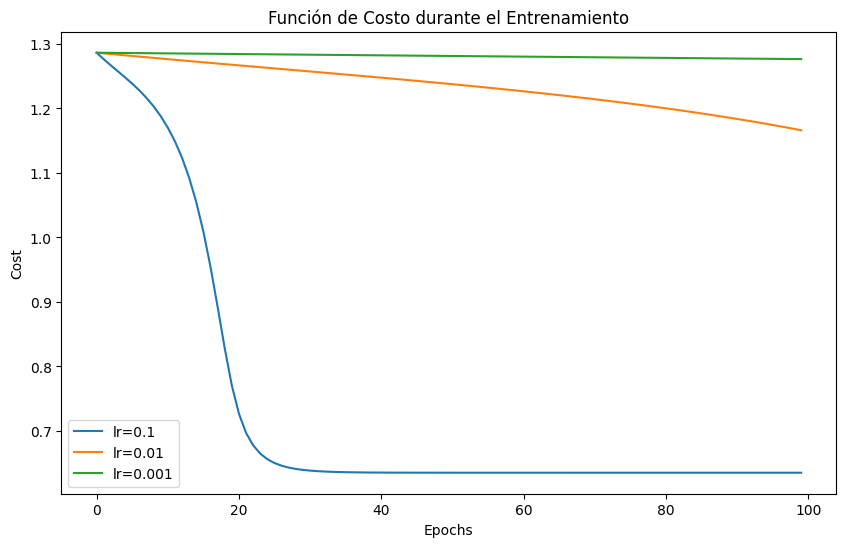

In [54]:
def forward(w, b, x):
    z = w*x + b
    y_hat = np.tanh(z)
    return y_hat

def cost(y_hat, y):
    return np.mean((y_hat - y)**2)

def gradients(y_hat, x, y):
    error = y_hat - y
    dz = error * (1 - y_hat**2)   # derivada de tanh
    dw = 2 * np.mean(dz * x)
    db = 2 * np.mean(dz)
    return dw, db

def gradient_descent(x, y, w0, b0, lr, epochs=100):
    w, b = w0, b0
    cost_history, w_history, b_history = [], [], []
    for epoch in range(epochs):
        y_hat = forward(w, b, x)
        cost_history.append(cost(y_hat, y))
        w_history.append(w)
        b_history.append(b)
        dw, db = gradients(y_hat, x, y)
        w -= lr * dw
        b -= lr * db
    return w, b, cost_history, w_history, b_history

# --- Entrenamiento del modelo ---
w0, b0 = np.random.randn(), np.random.randn()
lr = [0.1, 0.01, 0.001]
epochs = 100

w_a, b_a, cost_history_gd_a, w_history_gd_a, b_history_gd_a = gradient_descent(x, y, w0, b0, lr[0], epochs)
w_b, b_b, cost_history_gd_b, w_history_gd_b, b_history_gd_b = gradient_descent(x, y, w0, b0, lr[1], epochs)
w_c, b_c, cost_history_gd_c, w_history_gd_c, b_history_gd_c = gradient_descent(x, y, w0, b0, lr[2], epochs)

# --- Visualización de la función de costo ---
plt.figure(figsize=(10, 6))
plt.plot(cost_history_gd_a, label=f'lr={lr[0]}')
plt.plot(cost_history_gd_b, label=f'lr={lr[1]}')
plt.plot(cost_history_gd_c, label=f'lr={lr[2]}')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Función de Costo durante el Entrenamiento')
plt.legend()
plt.show()


## b) Implementación de Adam

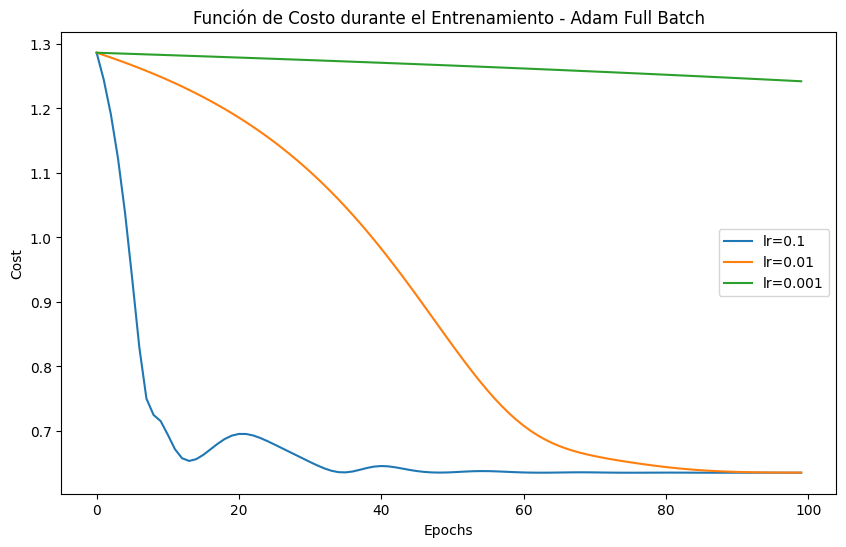

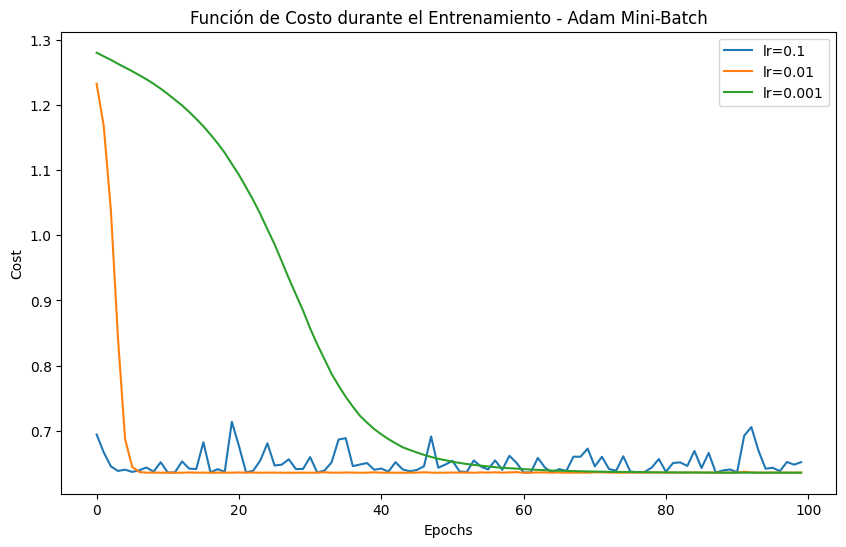

In [55]:
def adam_step(theta, g, m, v, t, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1*m + (1-beta1)*g
    v = beta2*v + (1-beta2)*(g**2)
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
    return theta, m, v

def adam_full_batch(x, y, w0, b0, lr, epochs=100):
    w, b = w0, b0
    mw, vw, mb, vb = 0, 0, 0, 0
    cost_history, w_history, b_history = [], [], []
    for epoch in range(1, epochs+1):
        y_hat = forward(w, b, x)
        cost_history.append(cost(y_hat, y))
        dw, db = gradients(y_hat, x, y)
        w, mw, vw = adam_step(w, dw, mw, vw, epoch, lr)
        b, mb, vb = adam_step(b, db, mb, vb, epoch, lr)
        w_history.append(w)
        b_history.append(b)
    return w, b, cost_history, w_history, b_history

def adam_minibatch(x, y, w0, b0, lr, epochs=100, batch_size=16):
    w, b = w0, b0
    mw, vw, mb, vb = 0, 0, 0, 0
    cost_history, w_history, b_history = [], [], []
    m = len(x)
    t = 0
    for epoch in range(epochs):
        idx = np.random.permutation(m)
        x_shuffled, y_shuffled = x[idx], y[idx]
        epoch_costs = []
        for start in range(0, m, batch_size):
            x_batch = x_shuffled[start:start+batch_size]
            y_batch = y_shuffled[start:start+batch_size]
            t += 1
            y_hat = forward(w, b, x_batch)
            epoch_costs.append(cost(y_hat, y_batch))
            dw, db = gradients(y_hat, x_batch, y_batch)
            w, mw, vw = adam_step(w, dw, mw, vw, t, lr)
            b, mb, vb = adam_step(b, db, mb, vb, t, lr)
        # Para comparar correctamente,conviene loguear el costo sobre todo el dataset al final de la época
        cost_history.append(cost(forward(w, b, x), y))
        w_history.append(w)
        b_history.append(b)
    return w, b, cost_history, w_history, b_history

# --- Entrenamiento del modelo ---
# Aclaración: se utilizan w0 y b0 iniciales para todos los experimentos, obtenidos en la sección anterior.

# --- Adam full batch ---
w_adam_a, b_adam_a, cost_history_adam_a, w_history_adam_a, b_history_adam_a = adam_full_batch(x, y, w0, b0, lr[0], epochs)
w_adam_b, b_adam_b, cost_history_adam_b, w_history_adam_b, b_history_adam_b = adam_full_batch(x, y, w0, b0, lr[1], epochs)
w_adam_c, b_adam_c, cost_history_adam_c, w_history_adam_c, b_history_adam_c = adam_full_batch(x, y, w0, b0, lr[2], epochs)

# --- Adam mini-batch ---
w_adam_mb_a, b_adam_mb_a, cost_history_adam_mb_a, w_history_adam_mb_a, b_history_adam_mb_a = adam_minibatch(x, y, w0, b0, lr[0], epochs)
w_adam_mb_b, b_adam_mb_b, cost_history_adam_mb_b, w_history_adam_mb_b, b_history_adam_mb_b = adam_minibatch(x, y, w0, b0, lr[1], epochs)
w_adam_mb_c, b_adam_mb_c, cost_history_adam_mb_c, w_history_adam_mb_c, b_history_adam_mb_c = adam_minibatch(x, y, w0, b0, lr[2], epochs)

# --- Visualización de la función de costo Adam full batch ---
plt.figure(figsize=(10, 6))
plt.plot(cost_history_adam_a, label=f'lr={lr[0]}')
plt.plot(cost_history_adam_b, label=f'lr={lr[1]}')
plt.plot(cost_history_adam_c, label=f'lr={lr[2]}')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Función de Costo durante el Entrenamiento - Adam Full Batch')
plt.legend()
plt.show()

# --- Visualización de la función de costo Adam mini-batch ---
plt.figure(figsize=(10, 6))
plt.plot(cost_history_adam_mb_a, label=f'lr={lr[0]}')
plt.plot(cost_history_adam_mb_b, label=f'lr={lr[1]}')
plt.plot(cost_history_adam_mb_c, label=f'lr={lr[2]}')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Función de Costo durante el Entrenamiento - Adam Mini-Batch')
plt.legend()
plt.show()

## c) Comparativa de optimizadores

Se realiza una comparación de GD vs Adam full batch vs Adam mini-batch para cada learning rate por separado

Optimizador          lr     Costo final  Costo minimo Ep. 95% reduccion 
Gradient Descent     0.1    0.63533      0.63533      23                
Adam Full Batch      0.1    0.63533      0.63533      12                
Adam Mini-Batch      0.1    0.65159      0.63559      3                 
Gradient Descent     0.01   1.16623      1.16623      97                
Adam Full Batch      0.01   0.63554      0.63554      68                
Adam Mini-Batch      0.01   0.63551      0.63533      5                 
Gradient Descent     0.001  1.27646      1.27646      94                
Adam Full Batch      0.001  1.24211      1.24211      95                
Adam Mini-Batch      0.001  0.63540      0.63539      45                


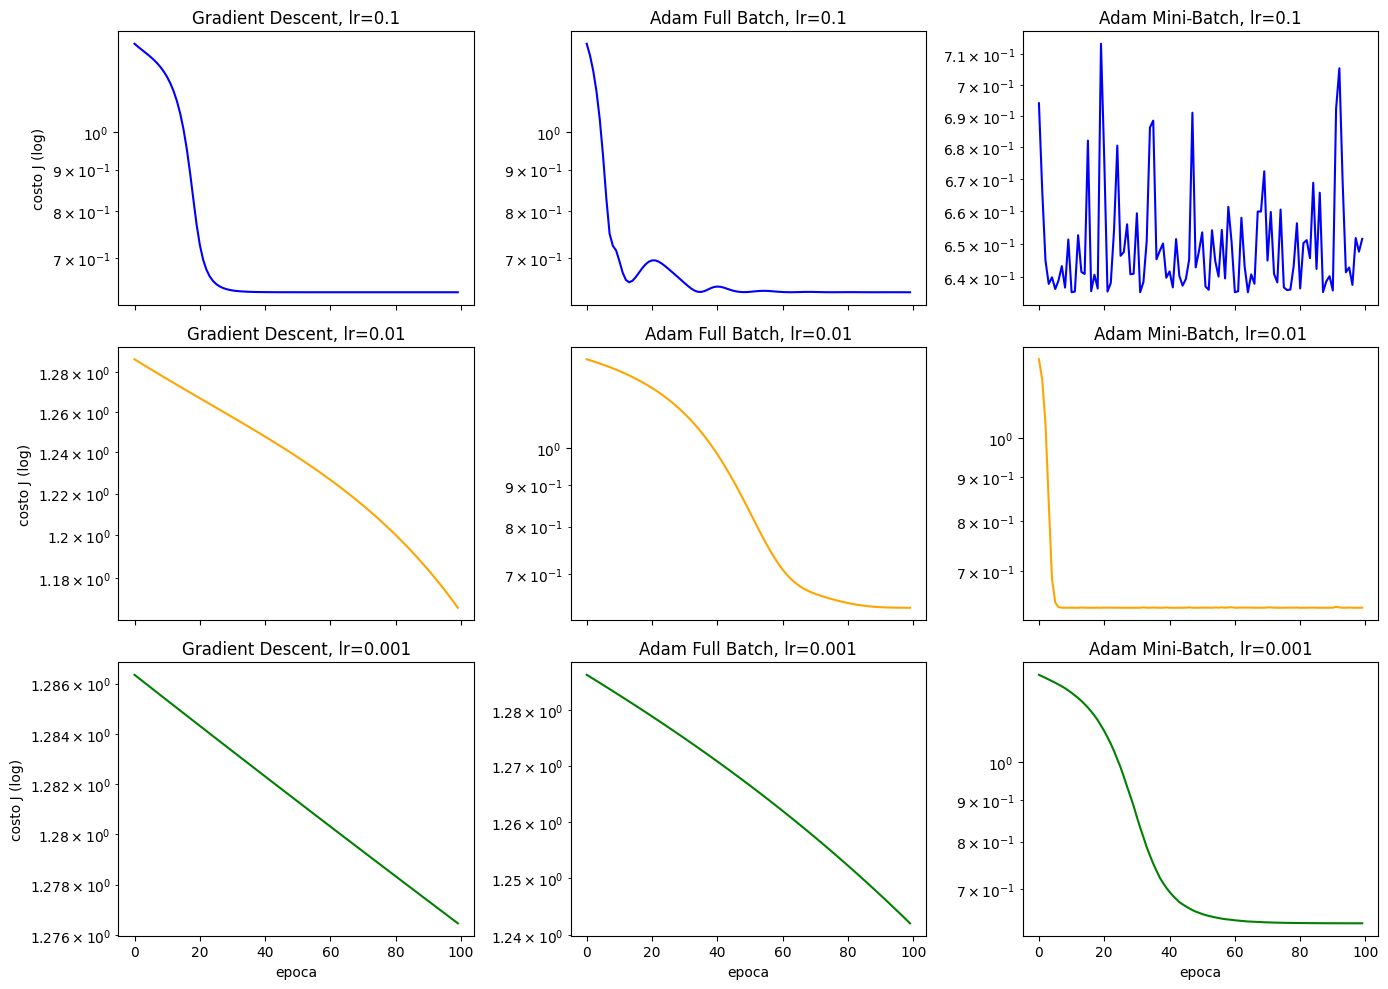

In [38]:
results = {}
cost_history_gd = [cost_history_gd_a, cost_history_gd_b, cost_history_gd_c]
cost_history_adam = [cost_history_adam_a, cost_history_adam_b, cost_history_adam_c]
cost_history_adam_mb = [cost_history_adam_mb_a, cost_history_adam_mb_b, cost_history_adam_mb_c]

for i in range(len(lr)):
    results[('Gradient Descent', lr[i])] = cost_history_gd[i]
    results[('Adam Full Batch', lr[i])] = cost_history_adam[i]
    results[('Adam Mini-Batch', lr[i])] = cost_history_adam_mb[i]

# --- Figura 3x3 ---
fig, axes = plt.subplots(3, 3, figsize=(14,10), sharex=True)
optimizers = ['Gradient Descent', 'Adam Full Batch', 'Adam Mini-Batch']
for i, lrs in enumerate(lr):
    colors = ['blue', 'orange', 'green']
    for j, opt in enumerate(optimizers):
        ax = axes[i][j]
        hist = results[(opt, lrs)]
        ax.plot(hist, color=colors[i])
        ax.set_title(f"{opt}, lr={lrs}")
        ax.set_yscale('log')
        if i==2: ax.set_xlabel("epoca")
        if j==0: ax.set_ylabel("costo J (log)")
plt.tight_layout()

# --- Tabla comparativa de costos finales ---

print(f"{'Optimizador':20s} {'lr':6s} {'Costo final':12s} {'Costo minimo':12s} {'Ep. 95% reduccion':18s}")
for lrs in lr:
    for opt in optimizers:
        hist = results[(opt, lrs)]
        final = hist[-1]
        minimo = min(hist)
        total_reduc = hist[0] - minimo
        target = hist[0] - 0.95*total_reduc
        ep95 = next((k for k,v in enumerate(hist) if v <= target), None)
        print(f"{opt:20s} {lrs:<6} {final:<12.5f} {minimo:<12.5f} {str(ep95):18s}")

#### Análisis de los gráficos

- **lr=0.1**: los tres optimizadores llegan rápido al mismo piso, alrededor de 0.635, pero Adam Mini-Batch queda oscilando de forma ruidosa alrededor del mínimo en lugar de estabilizarse. Esto se debe a que el paso es demasiado grande en ralación al ruido del mini-batch, entonces como que "rebota" alrededor del valor óptimo sin terminar de alcanzarlo.

- **lr = 0.01**: se puede observar la forma de "S" en GD y sobre todo en Adam Full-Batch, típico comportamiento que se produce al escapar de una meseta. La gráfica arranca plana, después cae rápido cuando el gradiente deja de estar saturado y se aplana de nuevo al converger. GD todavía no terminó de bajar del todo a las 100 épocas, mientras que Adama Full-Batch si llega a estabilizarse cerca de 0.65. Adam Mini-Batch, en cambio, ya cayó casi instantáneamente, cerca de 5 épocas.

- **lr = 0.001**: GD y Adam Full-Batch todavía no llegaron a la zona de despegue, son curvas que descienden muy despacio si observamos los valores del eje de ordenadas. Recién se encuentran empezando a salir de la meseta inicial de saturación de la $tanh$ y queda claro que no les alcanza con 100 épocas. En cambio, Adam Mini-Batch con el mismo *lr* ya completó la caída y llegó a 0.65 aproximadamente. Esto es coherente, ya que con menos pasos "efectivos", como el caso de una actualización por época en Full-Batch, el escape de la saturación es mucho más lento que con Mini-Batch.

Lo importante para destacar y explicar es la rapidez sistemática de Adam Mini-Batch, que se debe básicamente a que una época no representa lo mismo para estos tres optimizadores.
- En GD y Adam Full-Batch, cada época es igual a 1 sola actualización de los valores de $w$ y $b$. Se usa todo el dataset para un único paso del gradiente
- En Adam Mini-Batch, cada época es igual a varias actualizaciones, en concreto a $$\frac {n}{batch \, size}$$ donde en este caso $n=cantidad\,de\,datos=300$ y $batch\,size=tamaño\,del\,mini\,batch=16$. Esto equivale aproximadamente a 19 actualizaciones por época.

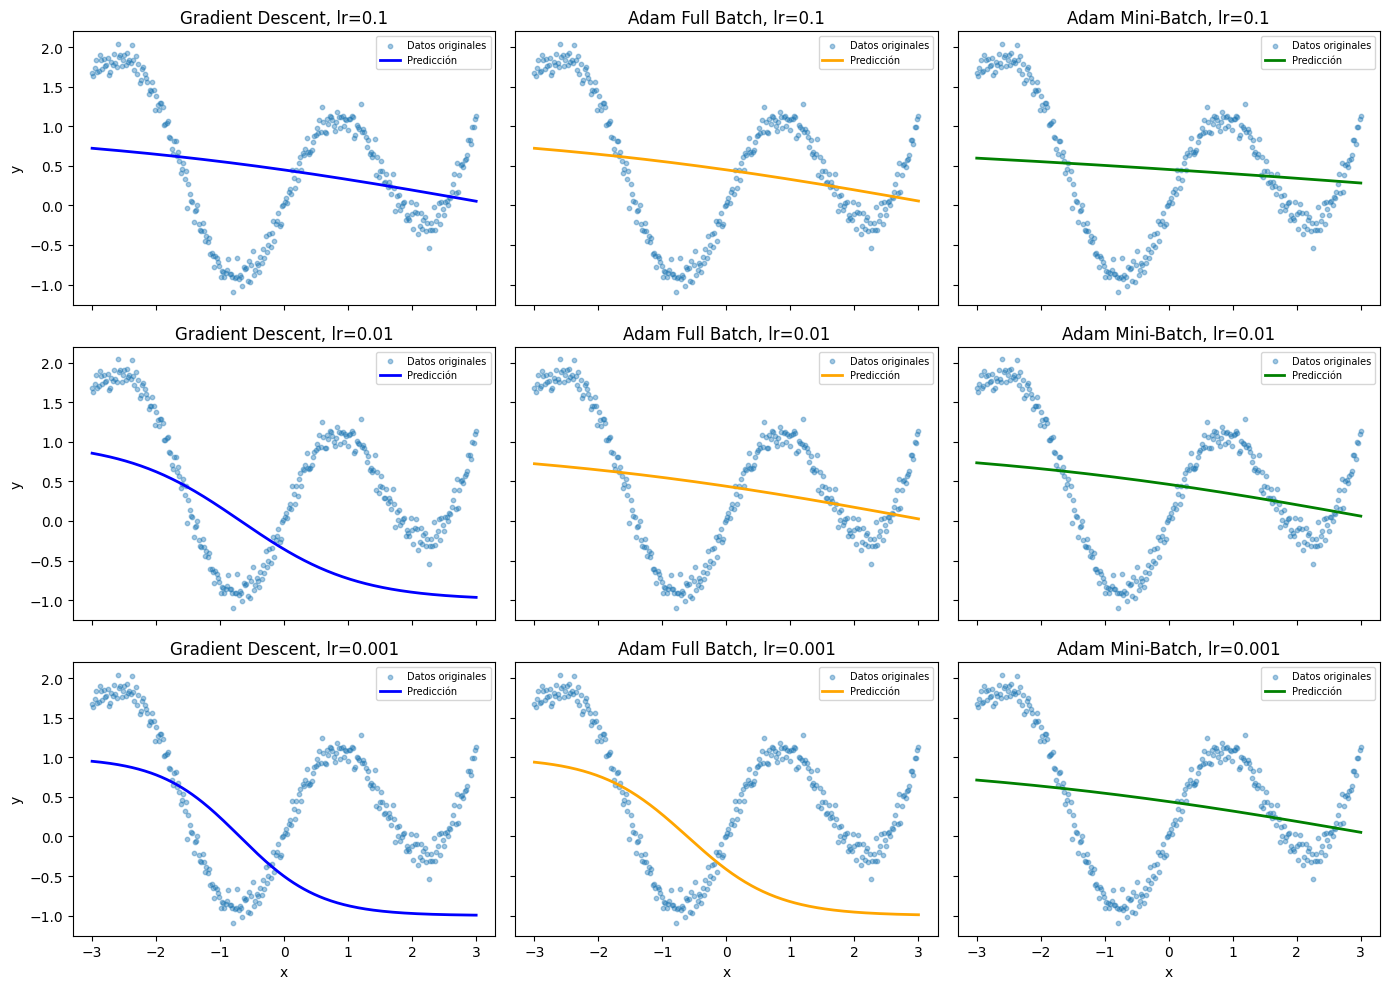

In [39]:
# --- Diccionario con los historiales de w y b de cada optimizador/lr ---
w_hist_gd = [w_history_gd_a, w_history_gd_b, w_history_gd_c]
b_hist_gd = [b_history_gd_a, b_history_gd_b, b_history_gd_c]

w_hist_adam = [w_history_adam_a, w_history_adam_b, w_history_adam_c]
b_hist_adam = [b_history_adam_a, b_history_adam_b, b_history_adam_c]

w_hist_adam_mb = [w_history_adam_mb_a, w_history_adam_mb_b, w_history_adam_mb_c]
b_hist_adam_mb = [b_history_adam_mb_a, b_history_adam_mb_b, b_history_adam_mb_c]

param_history = {}
for i in range(len(lr)):
    param_history[('Gradient Descent', lr[i])] = (w_hist_gd[i], b_hist_gd[i])
    param_history[('Adam Full Batch', lr[i])] = (w_hist_adam[i], b_hist_adam[i])
    param_history[('Adam Mini-Batch', lr[i])] = (w_hist_adam_mb[i], b_hist_adam_mb[i])

# --- Figura 3x3: dataset original vs predicción final ---
fig, axes = plt.subplots(3, 3, figsize=(14,10), sharex=True, sharey=True)
colors = {'Gradient Descent': 'blue', 'Adam Full Batch': 'orange', 'Adam Mini-Batch': 'green'}

for i, lrs in enumerate(lr):
    for j, opt in enumerate(optimizers):
        w_hist, b_hist = param_history[(opt, lrs)]
        w_final, b_final = w_hist[-1], b_hist[-1]   # último valor = parámetro final entrenado
        y_pred = forward(w_final, b_final, x)

        ax = axes[i][j]
        ax.scatter(x, y, alpha=0.4, s=10, label='Datos originales')
        ax.plot(x, y_pred, color=colors[opt], linewidth=2, label='Predicción')
        ax.set_title(f"{opt}, lr={lrs}")
        if i == 2: ax.set_xlabel("x")
        if j == 0: ax.set_ylabel("y")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

#### Análisis de los gráficos

El dataset sintético tiene forma de onda con dos oscilaciones completas, dos picos y dos valles, en el rango [-3,3]. Una sola neurona con $tanh$ solo puede producir una curva monótona en forma de S, sube o baja una sola vez, nunca podrá replicar ese comportamiento. Es por eso que ninguna predicción sigue la forma del seno. Todas las predicciones son, en el mejor de los casos, una S suave que "promedia" la tendencia general.
Lo que se puede llegar a detallar son las diferencias entre las soluciones encontradas por GD y Adam.
- GD con **lr=0.01** y **lr=0.001** logró una S mucho más pronunciada, yendo 0.9 a -1 aproximadamente, capturando al menos la tendencia descendente global del dataset. Con **lr=0.1** la S es más tibia, de 0.75 a 0.05, lo que indica que con paso grande es como si se hubiera pasado y quedó en una región más plana en vez de profundizar en la saturación.
- Adam (Full Batch y Mini-Batch), converge a una S mucho más tibia y casi idénticas entre sí, lo cual indica que el escalado adaptativo de Adam lo llevó a una región de *(w, b)* con menor magnitud, sin importar el lr.

Esto da una idea de que el optimizador no solo afecta valocidad de convergencia, sino a qué región del espacio de parámetro converge, y con una función no convexa como esta, distintos optimizadores pueden asentarse en soluciones distintas aunque el dataset sea el mismo.

## d) Visualización en 3D de la trayectoria de aprendizaje

In [40]:
w_range = np.linspace(-1, 1, 100)
b_range = np.linspace(-1, 1, 100)
W, B = np.meshgrid(w_range, b_range)

J_surface = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_hat_grid = forward(W[i, j], B[i, j], x)
        J_surface[i, j] = cost(y_hat_grid, y)


print("Verificación de longitudes:")
print(len(w_history_gd_a), len(b_history_gd_a), len(cost_history_gd_a))
# las tres tienen que dar el mismo número para verificar el tamaño de los historiales de w, b y costo

results_full = {}
cost_hist_gd = [cost_history_gd_a, cost_history_gd_b, cost_history_gd_c]
cost_hist_adam = [cost_history_adam_a, cost_history_adam_b, cost_history_adam_c]
cost_hist_adam_mb = [cost_history_adam_mb_a, cost_history_adam_mb_b, cost_history_adam_mb_c]

for i in range(len(lr)):
    results_full[('Gradient Descent', lr[i])] = (w_hist_gd[i], b_hist_gd[i], cost_hist_gd[i])
    results_full[('Adam Full Batch', lr[i])] = (w_hist_adam[i], b_hist_adam[i], cost_hist_adam[i])
    results_full[('Adam Mini-Batch', lr[i])] = (w_hist_adam_mb[i], b_hist_adam_mb[i], cost_hist_adam_mb[i])

Verificación de longitudes:
100 100 100


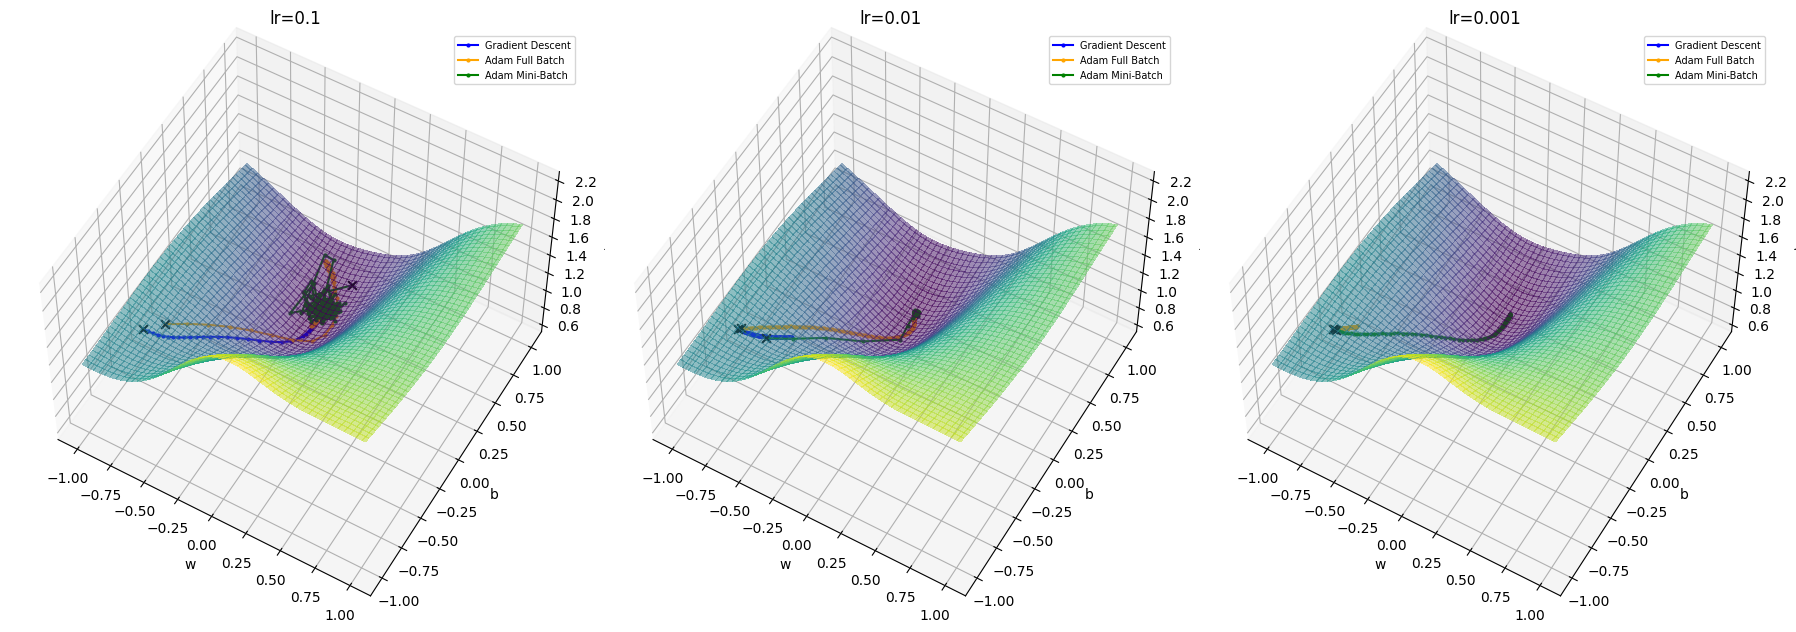

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 6))
colors = {'Gradient Descent': 'blue', 'Adam Full Batch': 'orange', 'Adam Mini-Batch': 'green'}

for i, lrs in enumerate(lr):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.plot_surface(W, B, J_surface, alpha=0.5, cmap='viridis', linewidth=0, antialiased=False)

    for opt in optimizers:
        w_hist, b_hist, cost_hist = results_full[(opt, lrs)]
        ax.plot(w_hist, b_hist, cost_hist, color=colors[opt], marker='o', markersize=2, linewidth=1.5, label=opt)
        ax.scatter([w_hist[0]], [b_hist[0]], [cost_hist[0]], color='black', s=40, marker='x')  # punto de partida

    ax.set_title(f"lr={lrs}")
    ax.set_xlabel("w")
    ax.set_ylabel("b")
    ax.set_zlabel("J")
    ax.legend(fontsize=7)
    ax.view_init(elev=55, azim=-60)  # ángulo de cámara

plt.tight_layout()
plt.show()

In [42]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig = plt.figure(figsize=(18, 6))
axes3d = []
lines = {}

for i, lrs in enumerate(lr):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.plot_surface(W, B, J_surface, alpha=0.5, cmap='viridis', linewidth=0, antialiased=False)
    ax.set_title(f"lr={lrs}")
    ax.set_xlabel("w"); ax.set_ylabel("b"); ax.set_zlabel("J")
    ax.view_init(elev=55, azim=-60)
    axes3d.append(ax)

    for opt in optimizers:
        line, = ax.plot([], [], [], color=colors[opt], marker='o', markersize=2, linewidth=1.5, label=opt)
        lines[(opt, lrs)] = line
    ax.legend(fontsize=7)

n_frames = epochs

def update(frame):
    artists = []
    for lrs in lr:
        for opt in optimizers:
            w_hist, b_hist, cost_hist = results_full[(opt, lrs)]
            line = lines[(opt, lrs)]
            line.set_data(w_hist[:frame+1], b_hist[:frame+1])
            line.set_3d_properties(cost_hist[:frame+1])
            artists.append(line)
    return artists

anim = FuncAnimation(fig, update, frames=n_frames, interval=60, blit=False)
anim.save("trayectorias_1d.gif", writer=PillowWriter(fps=15))
plt.close(fig)

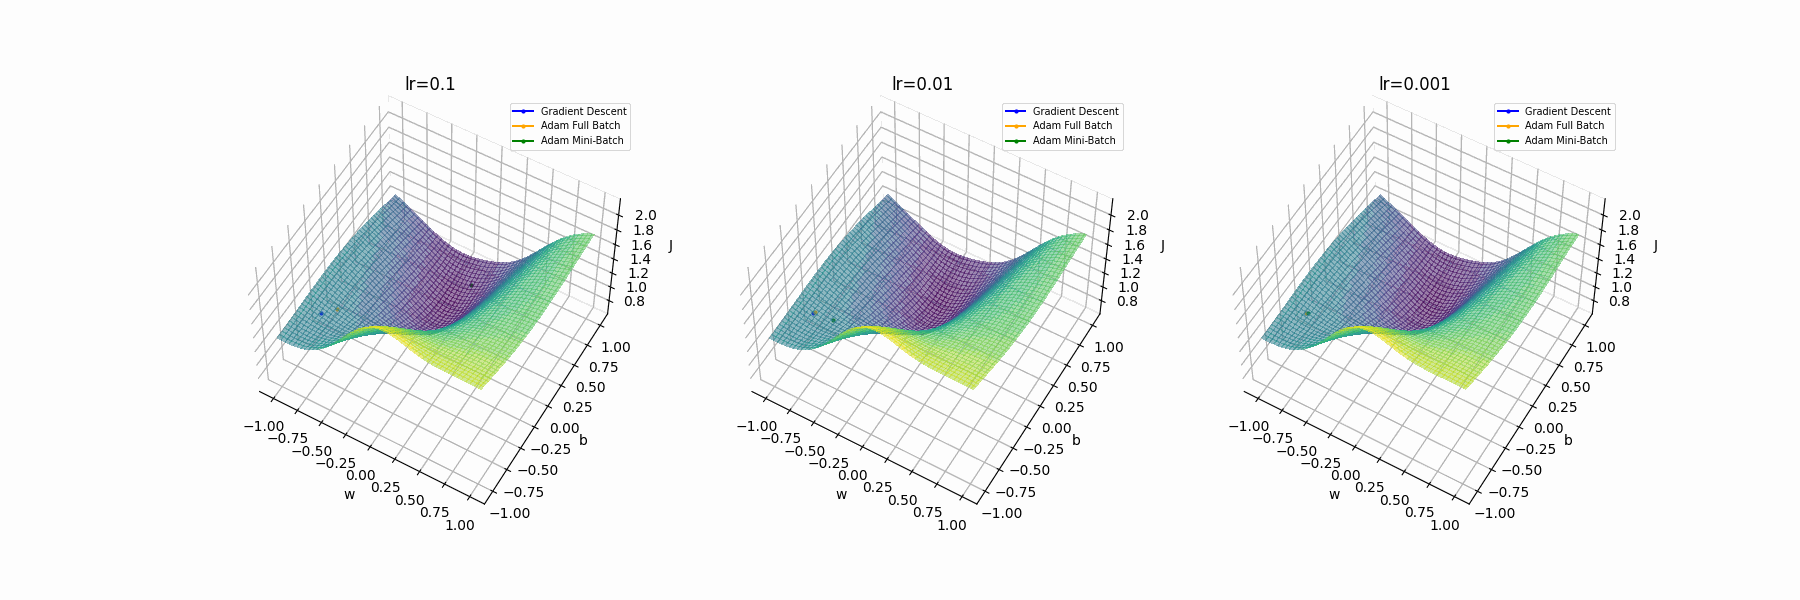

In [43]:
from IPython.display import Image
Image(filename="trayectorias_1d.gif")

#### Conclusiones finales

Analizando la superficie de costo, muestra una topología de "silla de montar", con dos montañas y un valle, lo cual es evidencia de que el problema no convexo planteado no tiene un único camino de descenso, sino una geometría donde distintos optimizadores pueden converger a regiones ligeramente distintas del valle según su punto de partida y la forma de recorrer el espacio.

Observando la trayectorias de los tres optimizadores sobre la superficie de costo $ J(w,b) $, se observan diferentes patrones de movimiento según el learning rate utilizado.
- Con **lr=0.001**, las tres trayectorias permanecen cortas y pegadas al punto de partida, lo cual es consistente con lo identificado en los gráficos de costo por época, en 100 iteraciones solo Adam Mini-Batch avanza significativamente, mientras que GD y Adam Full-Batch no lo hacen.
- Con **lr=0.01**, se aprecia que Adam Mini-Batch recorre un camino visiblemente más corto y directo, alcanzando una región más profunda en muchas menos iteraciones que Adam Full-Batch. GD no logra alcanzar el mismo lugar para esta cantidad de iteraciones.
- Con **lr=0.1**, GD muestra una trayectoria relativamente corta y suave hacia el mínimo. Adam Full-Batch hace un recorrido similar pero se excede en la búsqueda del mínimo, rebasando la zona de máxima profundidad y luego corrigiendo su trayectoria. Adam Mini-Batch muestra un recorrido caótico, oscilando de forma errática alrededor de una zona reducida de la superficie, cercana al valle, pero sin poder asentarse. Esto se debe a que el paso resulta demasiado grande en relación al ruido introducido por los mini-batches, lo cual genera un efecto rebote, que también se pudo ver en la curva de costo.

El análisis de las trayectorias en el espacio de parámetros son coherentes con lo observado en los gráficos de costo por época: GD y Adam Full-Batch se comportan de manera similar entre sí cuando la superficie no presenta ruido estocástico, difiriendo principalmente en velocidad (Adam converge algo más rápido gracias al momentum) pero no tanto en la forma cualitativa del camino recorrido. Adam Mini-Batch, en cambio, exhibe un comportamiento fuertemente dependiente del learning rate: con lr chico o moderado, su mayor cantidad de actualizaciones por época le permite escapar de mesetas y alcanzar regiones profundas del valle mucho más rápido que los métodos full-batch: con lr grande, ese mismo mecanismo se vuelve contraproducente, generando oscilación persistente en lugar de convergencia estable. Esto pone en evidencia un trade-off central en la optimización estocástica, donde el ruido introducido por el mini-batch puede actuar como mecanismo de escape de zonas planas de la superficie de costo (beneficioso con pasos pequeños), pero también como fuente de inestabilidad cuando se combina con pasos grandes. En términos prácticos, esto sugiere que la elección del learning rate para Adam Mini-Batch requiere más cautela que para los métodos full-batch, ya que su rango de valores "seguros" es más estrecho.

## PREGUNTA 2

## a) EDA y preparación del dataset

In [44]:
import pandas as pd

df = pd.read_csv("dataset_compras.csv")
df.head(10)

,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142
5,1047008,P00024740,18-25,M,0,A,2,5,16.0,NaN,353
6,1056762,P00067925,46-50,F,1,B,5+,17,24.0,16.0,117
7,1047329,P00003426,36-45,F,1,B,1,16,NaN,NaN,447
8,1042051,P00074117,46-50,F,1,B,5+,11,20.0,NaN,7831
9,1032071,P00039594,51-55,F,1,B,4,3,NaN,NaN,704


In [45]:
# --- Resumen General del dataset ---
num_row, num_col = df.shape
print(f"El dataset tiene {num_row} filas y {num_col} columnas.")

# --- Clasificación de las columnas ---
ID_COLS = ['User_ID', 'Product_ID']
CATEGORICAL_COLS = ['Age', 'Gender', 'Marital_Status', 'City_Category','Stay_In_Current_City_Years','Product_Category', 'Product_Subcategory_1','Product_Subcategory_2']
NUMERIC_COLS = ['Purchase']

id_cols             = [c for c in ID_COLS if c in df.columns]
categorical_cols    = [c for c in CATEGORICAL_COLS if c in df.columns]
numeric_cols        = [c for c in NUMERIC_COLS if c in df.columns]

null_pct = df.isnull().mean().sort_values(ascending=False)
high_null_cols = null_pct[null_pct > 0.2]

print("\n═════════════════════════")
print("  RESUMEN DEL DATASET  ")
print("═══════════════════════════")
print("Total de filas:", num_row)
print("Total de columnas:", num_col)
print("Columnas de ID:", len(id_cols))
print("Columnas categóricas:", len(categorical_cols))
print("Columnas numéricas:", len(numeric_cols))
print()
print("── Variables categóricas ──────────────")
for v in categorical_cols:
    n_unique = df[v].nunique()
    print(f"   • {v:<30} {n_unique} valores únicos")
print()
print("── Variables numéricas ──────────────")
for v in numeric_cols:
    print(f"   • {v}")
print()
print("── Features con > 40% nulos ──────────────")
if high_null_cols.empty:
    print("No hay columnas con más del 40% de valores nulos.")
else:
    for col, pct in high_null_cols.items():
        print(f"   • {col:<40} {pct*100:.1f}%")

El dataset tiene 182721 filas y 11 columnas.

═════════════════════════
  RESUMEN DEL DATASET  
═══════════════════════════
Total de filas: 182721
Total de columnas: 11
Columnas de ID: 2
Columnas categóricas: 8
Columnas numéricas: 1

── Variables categóricas ──────────────
   • Age                            7 valores únicos
   • Gender                         2 valores únicos
   • Marital_Status                 2 valores únicos
   • City_Category                  3 valores únicos
   • Stay_In_Current_City_Years     5 valores únicos
   • Product_Category               20 valores únicos
   • Product_Subcategory_1          33 valores únicos
   • Product_Subcategory_2          16 valores únicos

── Variables numéricas ──────────────
   • Purchase

── Features con > 40% nulos ──────────────
   • Product_Subcategory_2                    57.6%
   • Product_Subcategory_1                    22.9%


In [46]:
# --- Construccion dataset cliente ---
registros = []
for user_id, grupo in df.groupby('User_ID'):
    registro = {
        'User_ID': user_id,
        'Age': grupo['Age'].iloc[0],
        'Gender': grupo['Gender'].iloc[0],
        'Marital_Status': grupo['Marital_Status'].iloc[0],
        'City_Category': grupo['City_Category'].iloc[0],
        'Stay_In_Current_City_Years': grupo['Stay_In_Current_City_Years'].iloc[0],
        'Gasto_Promedio': grupo['Purchase'].mean()
    }
    category_counts = grupo['Product_Category'].value_counts(normalize=True)
    
    for cat in range (0, df['Product_Category'].nunique()):
        registro[f'freq_cat_{cat}'] = category_counts.get(cat,0.0)
    registros.append(registro)

df_clientes = pd.DataFrame(registros).fillna(0)
print(f"Se han procesado {len(registros)} usuarios")
print(df_clientes.shape)
print(df_clientes.isnull().sum())
print(df_clientes.describe())

Se han procesado 7432 usuarios
(7432, 27)
User_ID                       0
Age                           0
Gender                        0
Marital_Status                0
City_Category                 0
Stay_In_Current_City_Years    0
Gasto_Promedio                0
freq_cat_0                    0
freq_cat_1                    0
freq_cat_2                    0
freq_cat_3                    0
freq_cat_4                    0
freq_cat_5                    0
freq_cat_6                    0
freq_cat_7                    0
freq_cat_8                    0
freq_cat_9                    0
freq_cat_10                   0
freq_cat_11                   0
freq_cat_12                   0
freq_cat_13                   0
freq_cat_14                   0
freq_cat_15                   0
freq_cat_16                   0
freq_cat_17                   0
freq_cat_18                   0
freq_cat_19                   0
dtype: int64
            User_ID  Marital_Status  Gasto_Promedio  freq_cat_0   freq_cat_1  \
c

Skew target: 0.5393830891754141
Mediana target: 6330.212765957447
Rango del target entre 275.27 y 17231.14


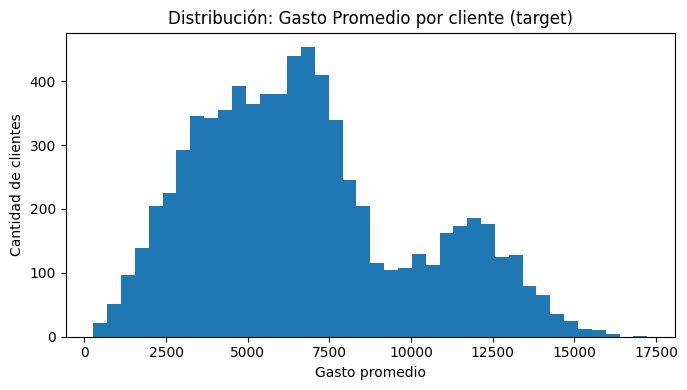

In [47]:
# --- Distribucion de la variable objetivo ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_clientes['Gasto_Promedio'], bins=40)
ax.set_title("Distribución: Gasto Promedio por cliente (target)")
ax.set_xlabel("Gasto promedio")
ax.set_ylabel("Cantidad de clientes")
plt.tight_layout()
 
print("Skew target:", df_clientes['Gasto_Promedio'].skew())
print("Mediana target:", df_clientes['Gasto_Promedio'].median())
print("Rango del target entre", df_clientes['Gasto_Promedio'].min().round(2), "y", df_clientes['Gasto_Promedio'].max().round(2))

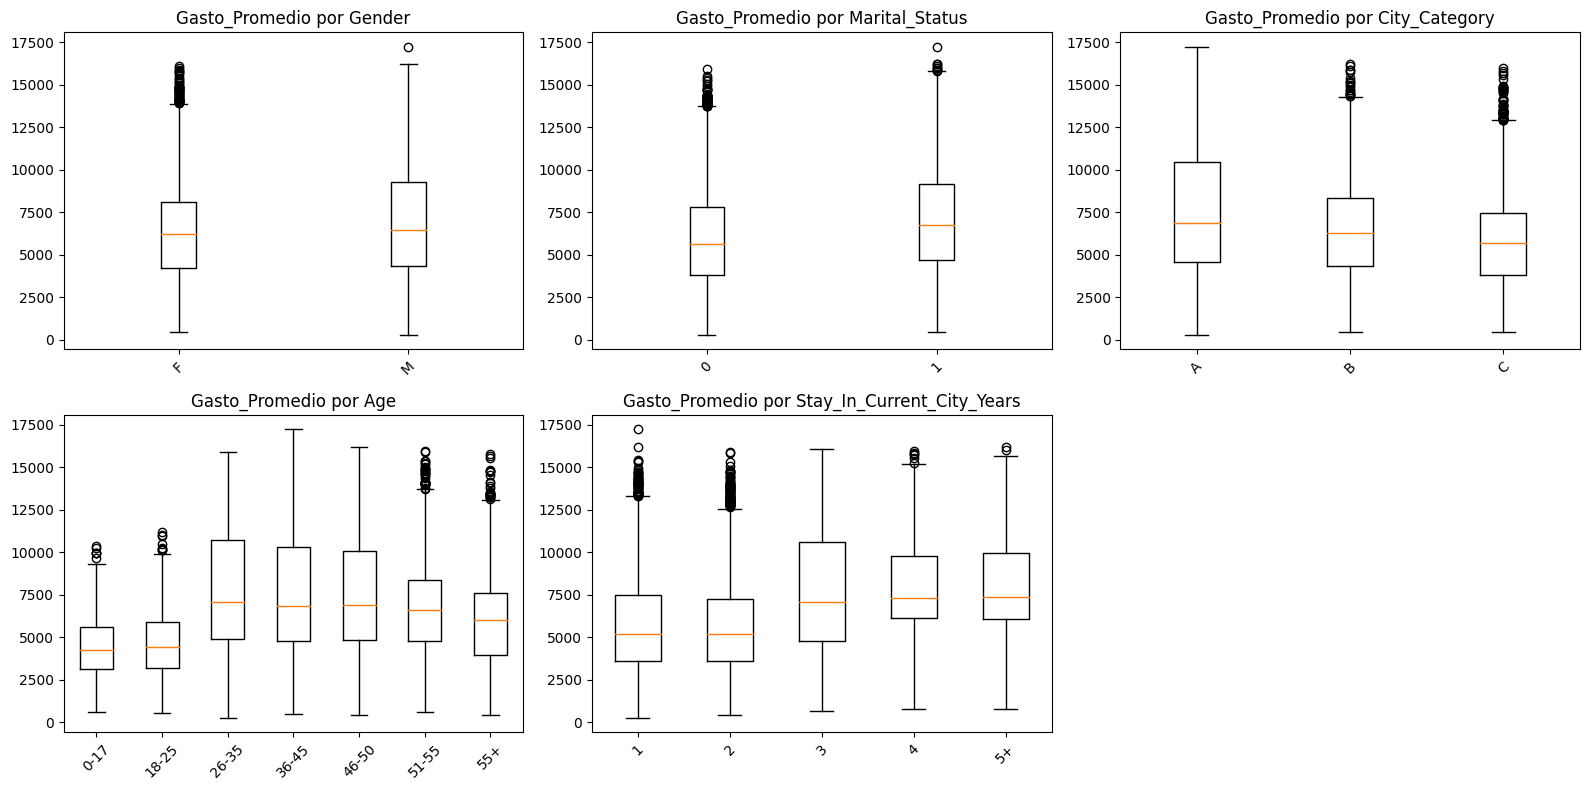

In [48]:
# --- Bloxplots por variable categórica ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cat_cols = ['Gender','Marital_Status','City_Category','Age','Stay_In_Current_City_Years']
for ax, col in zip(axes.flat, cat_cols):
    order = sorted(df_clientes[col].astype(str).unique())
    data = [df_clientes[df_clientes[col].astype(str)==o]['Gasto_Promedio'] for o in order]
    ax.boxplot(data, labels=order)
    ax.set_title(f"Gasto_Promedio por {col}")
    ax.tick_params(axis='x', rotation=45)
axes.flat[-1].axis('off')
plt.tight_layout()

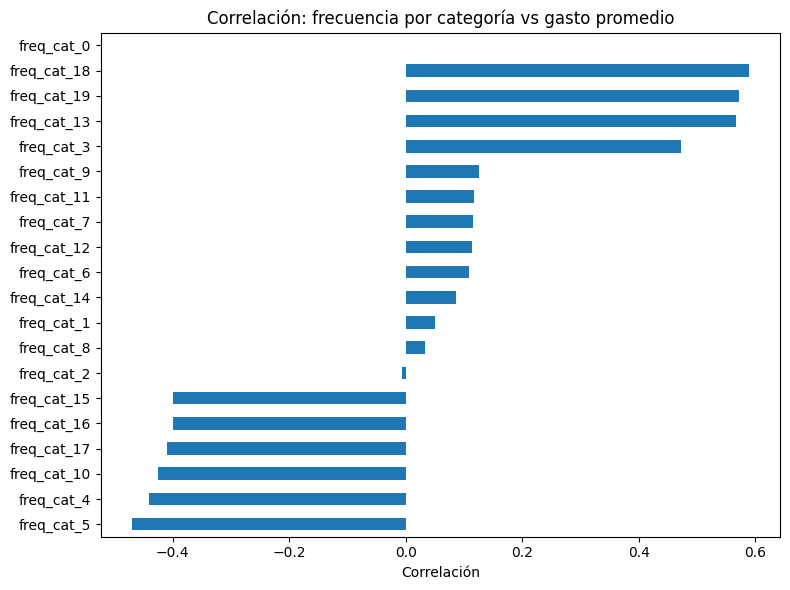

In [49]:
# --- Matriz de Correlación ---
freq_cols = [c for c in df_clientes.columns if c.startswith('freq_cat_')]
corr = df_clientes[freq_cols + ['Gasto_Promedio']].corr()['Gasto_Promedio'].drop('Gasto_Promedio').sort_values()
fig, ax = plt.subplots(figsize=(8,6))
corr.plot(kind='barh', ax=ax)
ax.set_title("Correlación: frecuencia por categoría vs gasto promedio")
ax.set_xlabel("Correlación")
plt.tight_layout()


In [50]:
# --- Encoding ordinal: Age y Stay_In_Current_City_Years ---
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
stay_order = ['1', '2', '3', '4', '5+']

df_clientes['Age_encoded'] = df_clientes['Age'].map({v:i for i, v in enumerate(age_order)})
df_clientes['Stay_encoded'] = df_clientes['Stay_In_Current_City_Years'].astype(str).map({v:i for i, v in enumerate(stay_order)})

# --- Encoding binario directo: Gender (Marital Status ya está codificado) ---
df_clientes['Gender_encoded'] = df_clientes['Gender'].map({'M': 1, 'F': 0})

# --- One-hot encoding: City_Category (nominal, sin orden de magnitud) ---
df_clientes = pd.get_dummies(df_clientes, columns=['City_Category'], prefix='City')

# --- Drop de columnas no necesarias para el modelo ---
drop_cols = ['User_ID', 'Age', 'Gender', 'Stay_In_Current_City_Years']
df_modelo = df_clientes.drop(columns=drop_cols)

print(df_modelo.shape)
print(df_modelo.dtypes)
print(df_modelo.head())
df_modelo.to_csv("dataset_clientes_procesado.csv", index=False)



(7432, 28)
Marital_Status      int64
Gasto_Promedio    float64
freq_cat_0        float64
freq_cat_1        float64
freq_cat_2        float64
freq_cat_3        float64
freq_cat_4        float64
freq_cat_5        float64
freq_cat_6        float64
freq_cat_7        float64
freq_cat_8        float64
freq_cat_9        float64
freq_cat_10       float64
freq_cat_11       float64
freq_cat_12       float64
freq_cat_13       float64
freq_cat_14       float64
freq_cat_15       float64
freq_cat_16       float64
freq_cat_17       float64
freq_cat_18       float64
freq_cat_19       float64
Age_encoded         int64
Stay_encoded        int64
Gender_encoded      int64
City_A               bool
City_B               bool
City_C               bool
dtype: object
   Marital_Status  Gasto_Promedio  freq_cat_0  freq_cat_1  freq_cat_2  \
0               0     1912.923077         0.0    0.000000     0.00000   
1               1    14338.906977         0.0    0.023256     0.00000   
2               1     4120.8

### Análisis del EDA

El dataset original contiene 182721 transacciones correspondientes a 7432 clientes únicos, con una gran variabilidad en la cantidad de compras por cliente (entre 10 y 50, con un promedio de 24,6). Dado que el objetivo del modelo es predecir el gasto promedio por cliente y no el gasto de una transacción individual, el primer paso del preprocesamiento consistió en agregar el dataset a nivel cliente, calculando el gasto promedio sobre la totalidad de sus compras registradas. Esta variable objetivo presenta una distribución con asimetría moderada (skew ≈ 0.54), un rango entre $275 y $17231, y una mediana de $6330, sin outliers extremos que requieran tratamiento especial.

En cuanto a las variables demográficas, se observaron diferencias claras en el gasto promedio según **Age** y **City_Category** (los clientes de 26 a 45 años y los de zona A muestran los promedios más altos), mientras que **Gender** y **Marital_Status** presentan una superposición considerable entre grupos, sugiriendo un poder predictivo individual más débil que se compensa al combinarse con otras variables dentro de un modelo no lineal.

Respecto a los valores faltantes, se detectó que **Product_Subcategory_1** y **Product_Subcategory_2** presentan 23% y 58% de nulos respectivamente. El análisis comparativo del gasto promedio entre registros con y sin subcategoría mostró diferencias en la mediana, indicando que la ausencia del dato podría ser en sí misma informativa, por lo que se optó por no imputar estos valores sino tratarlos como una categoría adicional.

Para capturar el patrón de compra de cada cliente sin incurrir en fugas de información, se construyeron variables de frecuencia relativa de compra por categoría de producto (**Product_Category**), calculadas sobre el historial completo disponible. Este enfoque permitió identificar categorías con correlación fuertemente positiva (**freq_cat_20: 0.61**, **freq_cat_18: 0.59**, **freq_cat_13: 0.57**) y otras con correlación fuertemente negativa (**freq_cat_5: -0.47**, **freq_cat_4: -0.43**) respecto al gasto promedio, evidenciando que la mezcla de categorías compradas por un cliente es un fuerte predictor de su nivel de gasto general.

Se evitó la construcción de variables derivadas de montos acumulados o de conteos absolutos de transacciones (cantidad total de compras o de categorías distintas visitadas), dado que ambos enfoques generan una dependencia indeseada. En el primer caso, al reconstruir la variable target tengo data leakage directo, mientras que el segundo introduce dependencia del modelo hacia un rango de valores.

## b) Modelo Multilayer Perceptron (MLP)

In [51]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import copy

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df = pd.read_csv("dataset_clientes_procesado.csv")

X = df.drop(columns=['Gasto_Promedio']).values.astype(np.float32)
y = df['Gasto_Promedio'].values.astype(np.float32).reshape(-1, 1)

# --- Split del dataset en train y test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Normalización de features ---
scaler_X = StandardScaler().fit(X_train)
X_train = scaler_X.transform(X_train).astype(np.float32)
X_test = scaler_X.transform(X_test).astype(np.float32)

scaler_y = StandardScaler().fit(y_train)
y_train_scaled = scaler_y.transform(y_train).astype(np.float32)
y_test_scaled = scaler_y.transform(y_test).astype(np.float32)

X_train_t = torch.tensor(X_train).to(device)
X_test_t = torch.tensor(X_test).to(device)
y_train_t = torch.tensor(y_train_scaled).to(device)
y_test_t = torch.tensor(y_test_scaled).to(device)

# --- Dataset y DataLoader ---
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 1),
).to(device)

lr = 0.001
batch_size = 32
epochs = 200
patience = 20

ds = TensorDataset(X_train_t, y_train_t)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)
 
opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
mse_loss = nn.MSELoss()

# --- Entrenamiento del modelo ---
loss_hist = []
r2_hist = []
best_test_loss = float('inf')
best_model_state = None
epochs_sin_mejora = 0
best_epoch = 0
 
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in dl:
        yhat = model(xb)
        loss = torch.sqrt(mse_loss(yhat, yb))  # RMSE
 
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    epoch_loss /= len(dl)
    loss_hist.append(epoch_loss)

    # --- Validación ---
    model.eval()
    with torch.no_grad():
        yhat_test = model(X_test_t)
        test_rmse = torch.sqrt(mse_loss(yhat_test, y_test_t)).item()
        y_true_np = y_test_t.view(-1).cpu().numpy()
        y_pred_np = yhat_test.view(-1).cpu().numpy()
        r2 = r2_score(y_true_np, y_pred_np)
        r2_hist.append(r2)

    if test_rmse < best_test_loss:
            best_test_loss = test_rmse
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_sin_mejora = 0
    else:
        epochs_sin_mejora += 1

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}  train_RMSE={epoch_loss:.4f}  test_RMSE={test_rmse:.4f}  test_R2={r2:.4f}")

    if epochs_sin_mejora >= patience:
        print(f"\nEarly stopping en epoca {epoch+1}. Mejor epoca: {best_epoch+1}")
        break

model.load_state_dict(best_model_state)

# --- Evaluación final del modelo ---
model.eval()
with torch.no_grad():
    yhat_test = model(X_test_t).cpu().numpy()
y_pred_test = scaler_y.inverse_transform(yhat_test)

r2_final = r2_score(y_test, y_pred_test)
rmse_final = np.sqrt(np.mean((y_test - y_pred_test)**2))
print(f"\nMLP compras RMSE={rmse_final:.2f}  R2={r2_final:.4f}  device={device}")

Epoch 20/200  train_RMSE=0.2871  test_RMSE=0.2506  test_R2=0.9339

Early stopping en epoca 38. Mejor epoca: 18

MLP compras RMSE=812.53  R2=0.9367  device=cpu


## c) Evaluación del Modelo

OK


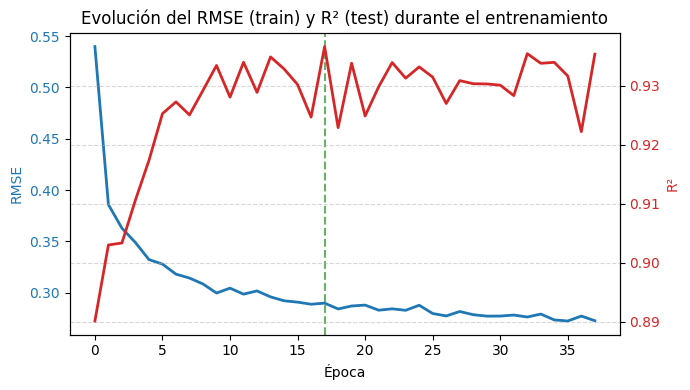

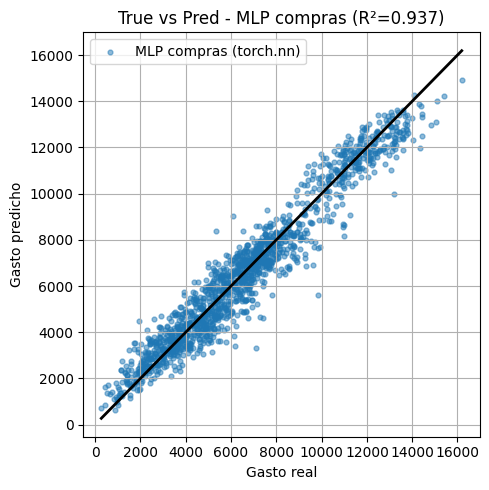

In [52]:
# --- Gráficas ---


# --- Evolución por época de la función de costo y del R^2
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(loss_hist, color='tab:blue', label='RMSE (train, escala estand.)', linewidth=2)
ax1.set_xlabel("Época")
ax1.set_ylabel("RMSE", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(r2_hist, color='tab:red', label='R² (test)', linewidth=2)
ax2.set_ylabel("R²", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.axvline(best_epoch, color='green', linestyle='--', alpha=0.6)
plt.title("Evolución del RMSE (train) y R² (test) durante el entrenamiento")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
 
# --- Scatter Real vs Predicción
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_test, s=12, alpha=0.5, label="MLP compras (torch.nn)")
m = float(min(y_test.min(), y_pred_test.min()))
M = float(max(y_test.max(), y_pred_test.max()))
plt.plot([m, M], [m, M], linewidth=2, color="black")
plt.xlabel("Gasto real")
plt.ylabel("Gasto predicho")
plt.title(f"True vs Pred - MLP compras (R²={r2_final:.3f})")
plt.legend()
plt.grid(True)
plt.tight_layout()
print("OK")

### Explicación y Justificación

El proceso de elaboración del modelo demandó ciertas iteraciones antes de llegar al diseño de features presentado. En primer lugar, se intentó simular el escenario de "cliente nuevo" truncando el historial de cliente a sus primeras compras y calculando el target sobre el resto de las transacciones, debido a una mala interpretación del enunciado. Con ese diseño, se tenía un techo de $R^2 \approx 0,42$, sin importar la arquitectura o los hiperparámetros utilizados. Esto evidenciaba un claro problema al restringirse en las primeras compras ya que el dataset no contiene ninguna variable temporal que permita determinar cuáles fueron las primeras compras de cada cliente.

Luego de la aclaración, se corrigió el enfoque para entrenar un modelo utilizando la totalidad de las trasacciones disponibles de cada cliente, evitando únicamente que las features dependan directamente de la cantidad acumulada de transacciones.

Bajo esta premisa se probaron dos variantes adicionales: primero, features de gasto acumulado por categoría de producto, que fueron descartadas al detectarse que su suma reconstruía trivialmente la variable objetivo (data leakage) y luego, conteos absolutos de categorías distintas visitadas, descartados por su alta correlación (0.91) con la cantidad total de transacciones del cliente, lo cual habría introducido una dependencia imposible de replicar en un escenario real. La solución final utilizó **frecuencia relativa de compra por categoría de producto**, calculada sobre el historial completo pero expresada como proporción.

Con este diseño, el modelo MLP, formado por 3 capas ocultas, Dropout y regularización L2, entrenado con Adam y early stopping, alcanzó un $R^2 \approx 0,937$ en el set de validación. La curva de evolución muestra que el RMSE de entrenamiento decrece de forma sostenida hasta estabilizarse cerca de 0.28, mientras que el $R^2$ de validación se estabiliza en torno a 0.92-0.93 desde las épocas 15~20, con cierta oscilación posterior propia del ruido de mini-batch, sin señales de overfitting entre train y validación. El early stopping intervino en la época 18, conservando el mejor punto observado. El scatter de valores reales contra valores predichos confirma este resultado: los puntos se distribuyen ajustados y simétricos alrededor de la recta identidad en todo el rango de gasto $(desde \, 0 \, hasta \, 16000)$, sin sesgos sistemáticos hacia la subestimación o sobreestimación en ningún tramo, ni compresión hacia la media.


## d) Conclusiones

El resultado final demuestra que el gasto promedio de un cliente está fuertemente asociado a su mezcla de categorías de producto compradas, más que a variables puramente demográficas o al volumen de su actividad transaccional. El proceso iterativo fue clave no solo para alcanzar un buen desempeño predictivo, sino para evitar dos tipos de errores metodológicos distintos pero igualmente problemáticos. En primer lugar, utilizar información que reconstruye la variable target y la dependencia espuria de features hacia una distribución de valores que no corresponde con el escenario real de uso del modelo, por ejemplo, para clientes nuevos con 3 a 5 visitas.